# Mouse Longitudinal CT to NPZ Conversion and Visualization

This notebook converts the 140 time-point subfolders of longitudinal mouse CT data into a single aggregated `.npz` format for testing.

In [1]:
import sys
from pathlib import Path
import os
import numpy as np

# Ensure project root is on sys.path
parent = Path().resolve().parent.parent 
if str(parent) not in sys.path:
    sys.path.append(str(parent))

from data.test_data.mouse_to_npz import process_mouse_longitudinal
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices

## 1. Process Mouse Longitudinal CT Dataset

We use the `process_mouse_longitudinal` function to compile the folders into a single bundle without downsampling, perfectly preserving the `0.28mm` isotropic metric.

In [ ]:
data_dir = "Mouse"
output_name = "Mouse"
organ_version = 1 # 10 classes in Organ1, 11 classes in Organ2 (adds Trachea)

# If running in data/test_data directory:
script_dir = os.path.abspath('')
data_path = os.path.join(script_dir, data_dir)
out_path = os.path.join(script_dir, output_name)

if os.path.isdir(data_path):
    process_mouse_longitudinal(data_path, out_path, organ_version)
else:
    print(f"Data directory {data_path} not found. Please ensure it exists.")

Discovered 35 longitudinal scan folders. Processing...
  [1/35] Processing M01_0.25h ...
  [2/35] Processing M01_002h ...
  [3/35] Processing M01_004h ...
  [4/35] Processing M01_008h ...
  [5/35] Processing M01_024h ...
  [6/35] Processing M01_048h ...
  [7/35] Processing M01_072h ...
  [8/35] Processing M02_0.25h ...
  [9/35] Processing M02_002h ...
  [10/35] Processing M02_004h ...
  [11/35] Processing M02_008h ...
  [12/35] Processing M02_024h ...
  [13/35] Processing M02_048h ...
  [14/35] Processing M02_072h ...
  [15/35] Processing M03_0.25h ...
  [16/35] Processing M03_002h ...
  [17/35] Processing M03_004h ...
  [18/35] Processing M03_008h ...
  [19/35] Processing M03_024h ...
  [20/35] Processing M03_048h ...
  [21/35] Processing M03_072h ...
  [22/35] Processing M04_0.25h ...
  [23/35] Processing M04_002h ...
  [24/35] Processing M04_004h ...
  [25/35] Processing M04_008h ...
  [26/35] Processing M04_024h ...
  [27/35] Processing M04_048h ...
  [28/35] Processing M04_072h ..

## 2. Load and Visualize

Now we load the generated `.npz` file and visualize a few samples from the longitudinal scans.

In [2]:
output_name = "Mouse_no_trachea"

In [6]:
# Path relative to project root since DataLoader_npz uses it
npz_path = f"data/test_data/{output_name}.npz"
parent_root = str(Path().resolve().parent.parent)
full_npz_path = os.path.join(parent_root, npz_path)

dg = DataGenerator(DataLoader_npz([full_npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids
print(f"Loaded IDs: len({len(all_ids)}) scans loaded")

sample_id = all_ids[3]
img = dg.dataloader.dataset[sample_id]['image']
mask = dg.dataloader.dataset[sample_id]['segmentations'][0]

print(f"Sample: {sample_id}")
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask.shape}")


Loading NPZ dataset(s)…
Loaded 35 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\Mouse_no_trachea.npz

Final dataset size: 35 patients.

Loaded IDs: len(35) scans loaded
Sample: Mouse_no_trachea_M03_048h
Image shape: (193, 108, 144)
Mask shape: (193, 108, 144)


### Static Persistent Visualization

This grid view is saved in the notebook, so you can see it later even without a running kernel.

In [7]:
img_clipped = np.clip(img, -1000, 1000)

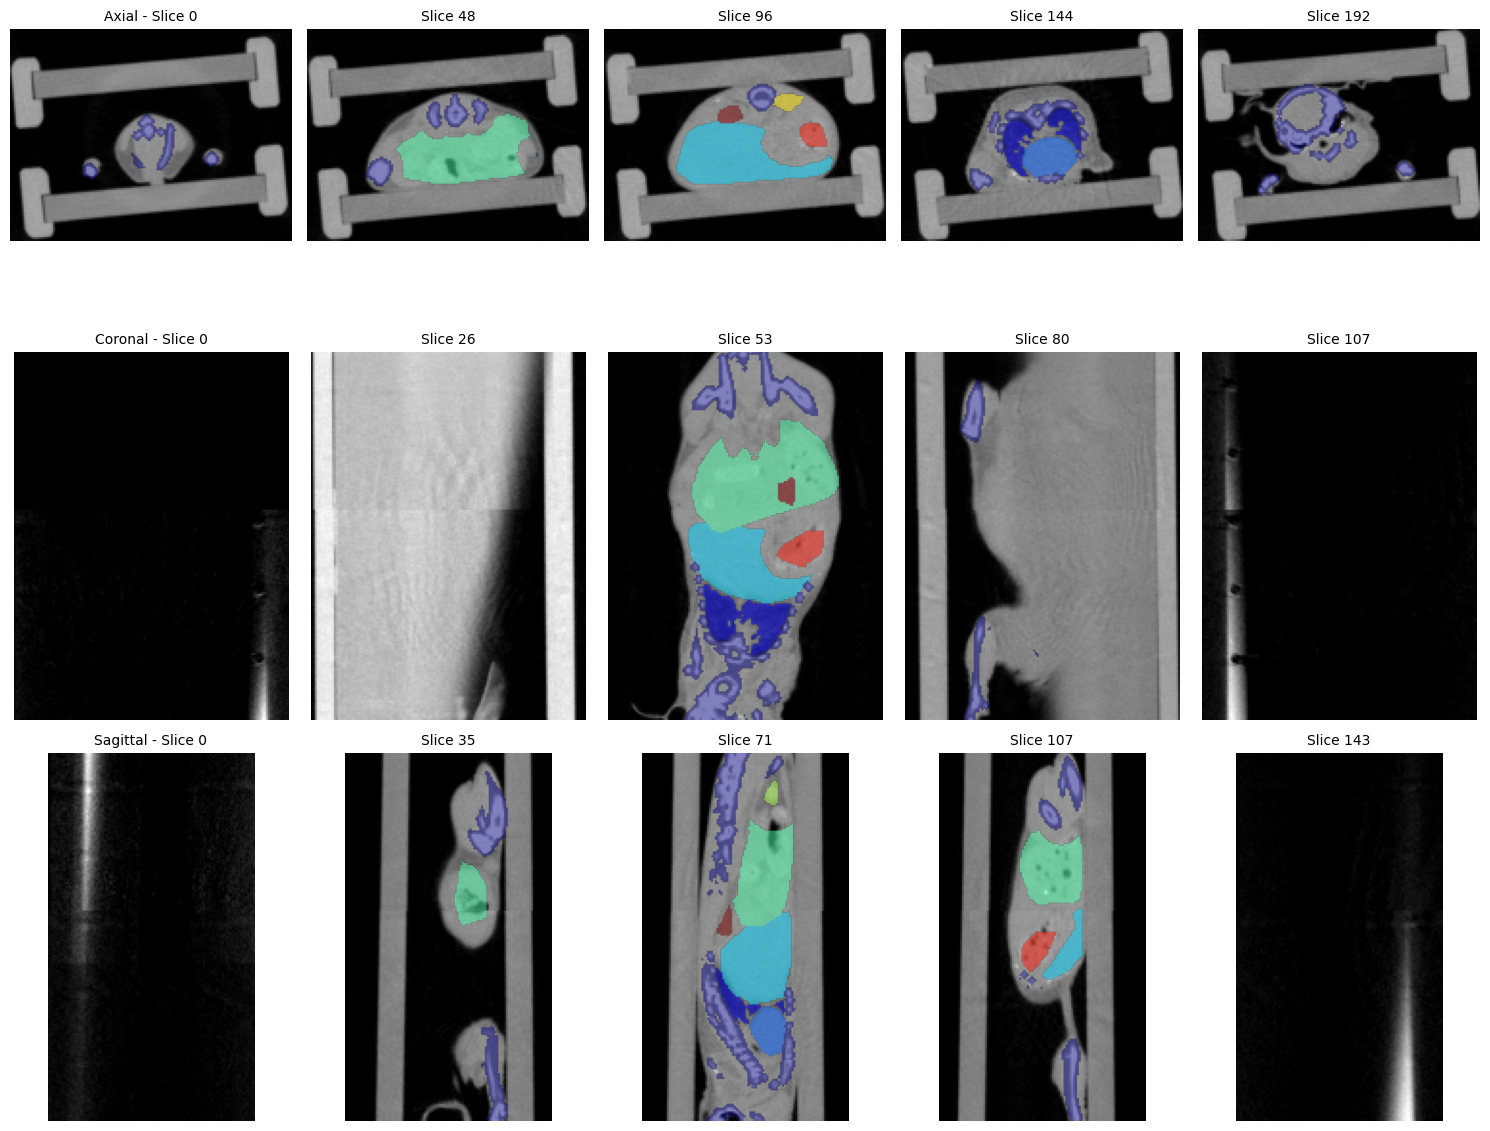

In [8]:
plot_vol_slices(img_clipped, mask, num_slices=5)